# 1. Introduction

This notebook uses Logistic Regression with Scikit-learn to predict Titanic passenger survival.

The project includes:

- Data loading
- Data exploration and visualization
- Data preprocessing and feature scaling
- Logistic Regression model training
- Model evaluation
- ROC Curve analysis
- Feature importance visualization

The model predicts whether a passenger survived based on demographic and ticket-related features.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_score, recall_score, roc_curve, f1_score
from sklearn.preprocessing import StandardScaler

# 2. Load Dataset

This section loads the Titanic dataset using Pandas.

It also displays:

- Statistical summaries of the dataset
- Missing value counts for each column

These checks help understand the structure and quality of the data before analysis.

In [3]:
df = pd.read_csv('../data/titanic.csv')

print(df.describe())
print(df.isnull().sum())

              sex         age  family_size       fare   1st_class   2nd_class  \
count  887.000000  887.000000   887.000000  887.00000  887.000000  887.000000   
mean     0.645998   29.471443     0.908681   32.30542    0.243517    0.207441   
std      0.478480   14.121908     1.615949   49.78204    0.429447    0.405703   
min      0.000000    0.420000     0.000000    0.00000    0.000000    0.000000   
25%      0.000000   20.250000     0.000000    7.92500    0.000000    0.000000   
50%      1.000000   28.000000     0.000000   14.45420    0.000000    0.000000   
75%      1.000000   38.000000     1.000000   31.13750    0.000000    0.000000   
max      1.000000   80.000000    10.000000  512.32920    1.000000    1.000000   

        3rd_class    survived  
count  887.000000  887.000000  
mean     0.549042    0.385569  
std      0.497870    0.487004  
min      0.000000    0.000000  
25%      0.000000    0.000000  
50%      1.000000    0.000000  
75%      1.000000    1.000000  
max      1.000

# 3. Data Exploration

This section explores patterns and relationships within the dataset using visualizations.

The analysis includes:

- Survival rates across binary passenger categories for eg. sex, 1st class, 2nd class etc
- Passenger age distribution
- Survival counts grouped by age ranges
- Correlation heatmap for numerical features

These visualizations help identify trends and important variables related to survival.

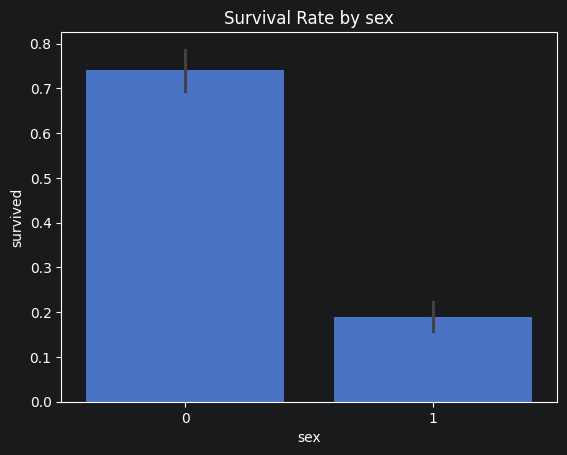

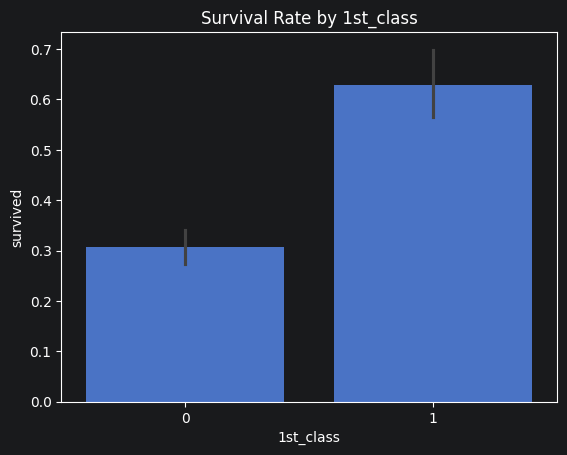

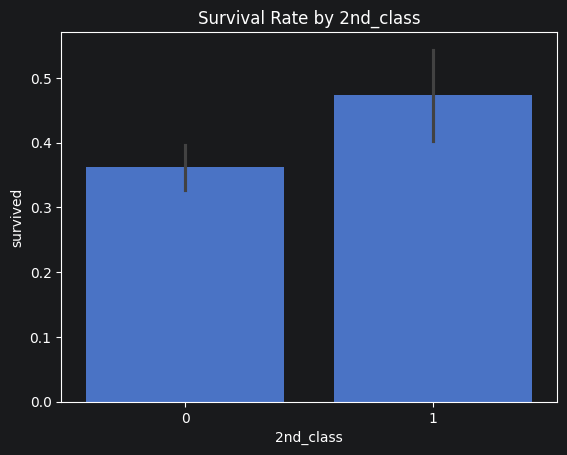

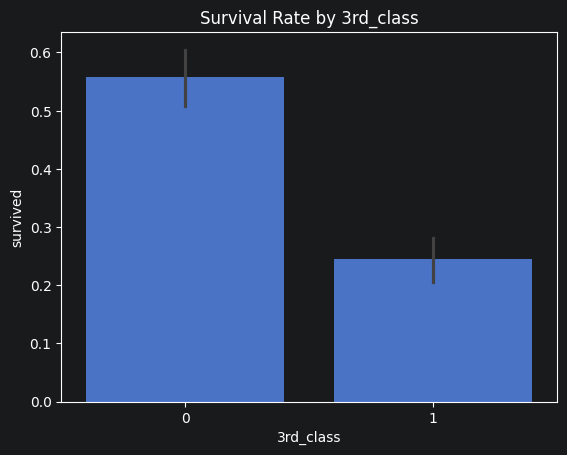

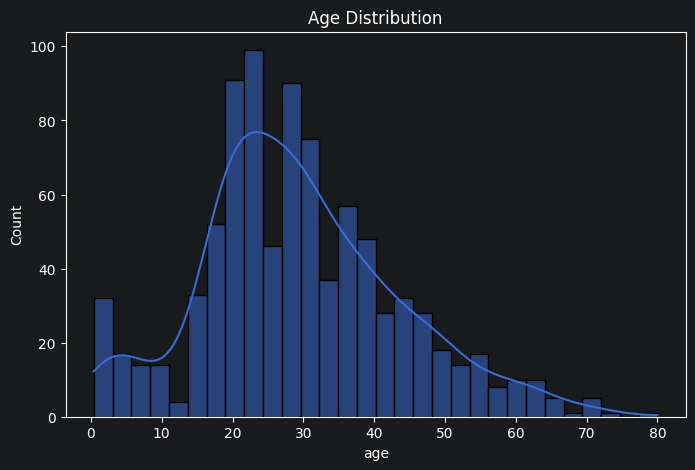

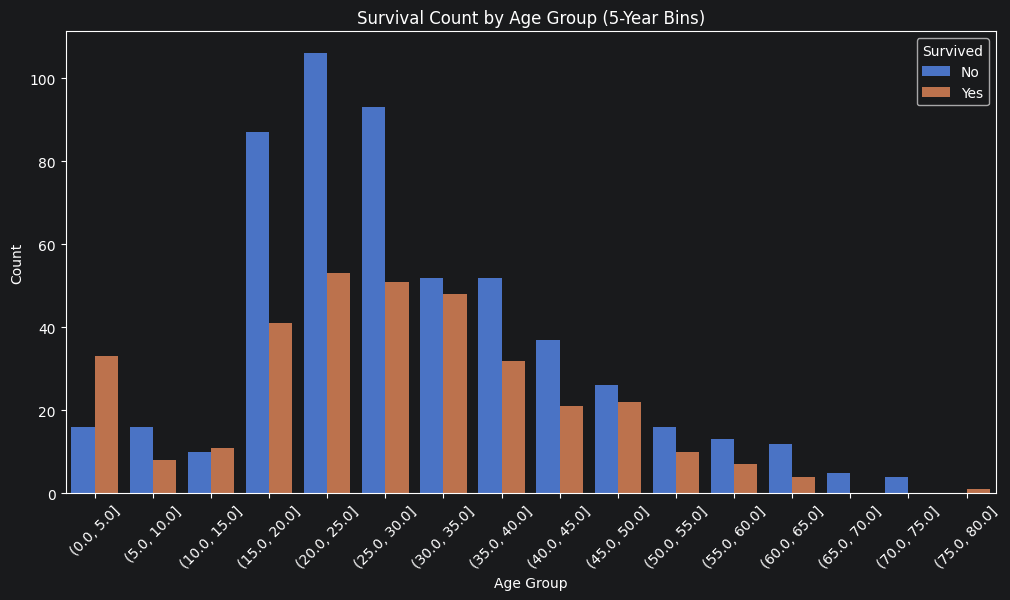

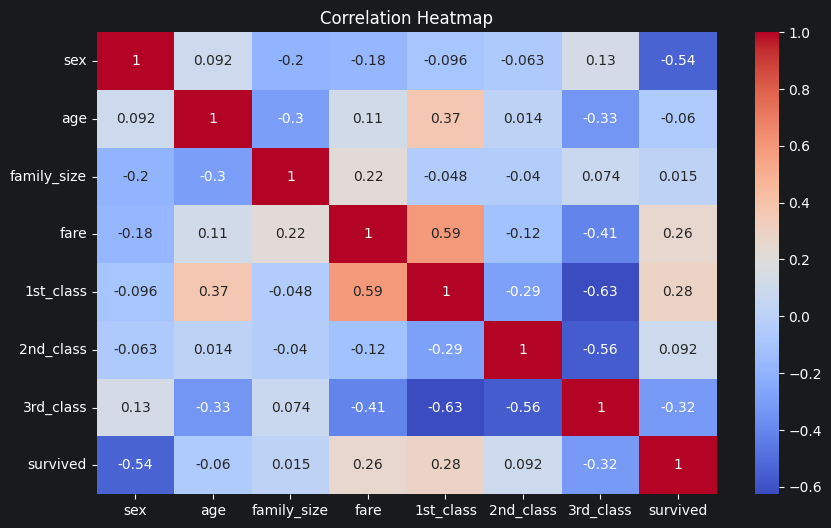

In [4]:
numeric_features = ["age", "family_size", "fare"]
binary_features = ["sex", "1st_class", "2nd_class", "3rd_class"]

for features in df.columns:
    if features in binary_features:
        sns.barplot(x=features, y='survived', data=df)
        plt.title('Survival Rate by {features}'.format(features=features))
        plt.show()

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

#Age group by survivors
viz_df = df.copy()
bins = np.arange(0, viz_df['age'].max() + 5, 5)
viz_df['age_group'] = pd.cut(viz_df['age'], bins=bins)
plt.figure(figsize=(12,6))

sns.countplot(
    data=viz_df,
    x='age_group',
    hue='survived'
)
plt.xticks(rotation=45)
plt.title('Survival Count by Age Group (5-Year Bins)')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()


# Correlation heatmap for numerical columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# 4. Data Cleaning and Preprocessing

This section prepares the dataset for machine learning.

The preprocessing steps include:

- Separating features and target variable
- Splitting the dataset into training and testing sets
- Standardizing numerical features using `StandardScaler`
- Applying transformations using `ColumnTransformer`

Feature scaling improves model performance and training stability.



In [5]:
# Define Features (X) and Target (Y)
X = df.drop(columns=['survived', '2nd_class', 'family_size'])
y = df['survived']

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ["age", "fare"]
binary_features = ["sex", "1st_class", "3rd_class"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="passthrough"
)

x_train_standardized = preprocessor.fit_transform(X_train)
x_test_standardized = preprocessor.transform(X_test)


# 5. Model Training

This section trains a Logistic Regression model using Scikit-learn.

The model uses:

- `max_iter=200` to allow sufficient training iterations
- `class_weight='balanced'` to handle class imbalance

The model learns relationships between passenger features and survival outcomes.

In [6]:
model = LogisticRegression(
    max_iter=200,
    class_weight='balanced'
)
model.fit(x_train_standardized, y_train)

/Users/KetakiJambhekar/PycharmProjects/MLOps/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/KetakiJambhekar/PycharmProjects/MLOps/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/KetakiJambhekar/PycharmProjects/MLOps/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression(class_weight='balanced', max_iter=200)

# 6. Predictions

This section generates predictions using the trained model.

The outputs include:

- Predicted survival classes
- Predicted survival probabilities

These predictions are later used for performance evaluation.

In [7]:
y_pred = model.predict(x_test_standardized)
y_prob = model.predict_proba(x_test_standardized)[:, 1]

# 7. Model Evaluation

This section evaluates model performance using several classification metrics.

The evaluation includes:

- Confusion Matrix
- Classification Report
- Accuracy Score
- Precision Score
- Recall Score
- F1 Score
- ROC-AUC Score

These metrics measure how well the model predicts passenger survival.

The confusion matrix is also visualized using a heatmap.


===== CONFUSION MATRIX =====
[[92 19]
 [17 50]]


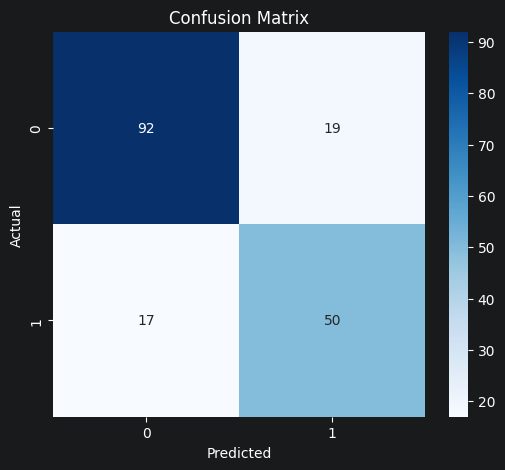


===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.84      0.83      0.84       111
           1       0.72      0.75      0.74        67

    accuracy                           0.80       178
   macro avg       0.78      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178

Accuracy Score: 0.80
Precision Score: 0.72
Recall Score: 0.75
F1 Score: 0.74


In [8]:
print("\n===== CONFUSION MATRIX =====")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {accuracy:.2f}")

# Precision
precision = precision_score(y_test, y_pred)
print(f"Precision Score: {precision:.2f}")

# Recall
recall = recall_score(y_test, y_pred)
print(f"Recall Score: {recall:.2f}")

# F1 Score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1:.2f}")



# 8. ROC Curve

This section visualizes the Receiver Operating Characteristic (ROC) Curve.

The ROC Curve shows the relationship between:

- True Positive Rate
- False Positive Rate

The Area Under the Curve (AUC) measures the model’s ability to distinguish between survival classes.

Higher AUC values indicate better classification performance.

ROC AUC Score: 0.81


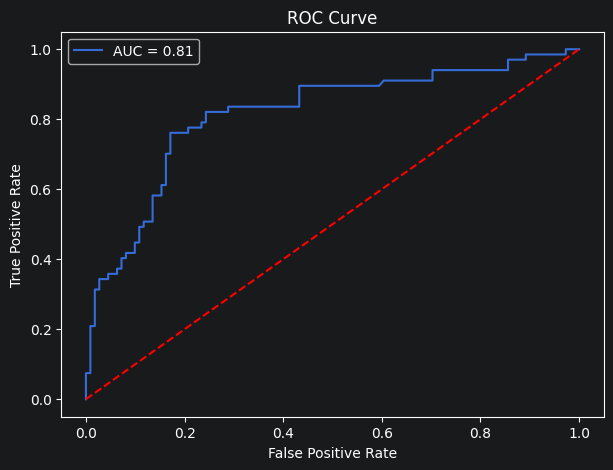

In [9]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC AUC Score: {roc_auc:.2f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='red')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

# 9. Feature Importance

This section analyzes feature importance using Logistic Regression coefficients.

Features with:

- Positive coefficients increase survival probability
- Negative coefficients decrease survival probability

The coefficients are displayed in both:

- Table format
- Bar chart visualization

This helps identify which passenger attributes most influenced survival predictions.


===== FEATURE IMPORTANCE =====
     Feature  Coefficient
3  1st_class     0.914802
1        age     0.094312
0        sex    -0.395520
4  3rd_class    -1.135932
2       fare    -2.498060


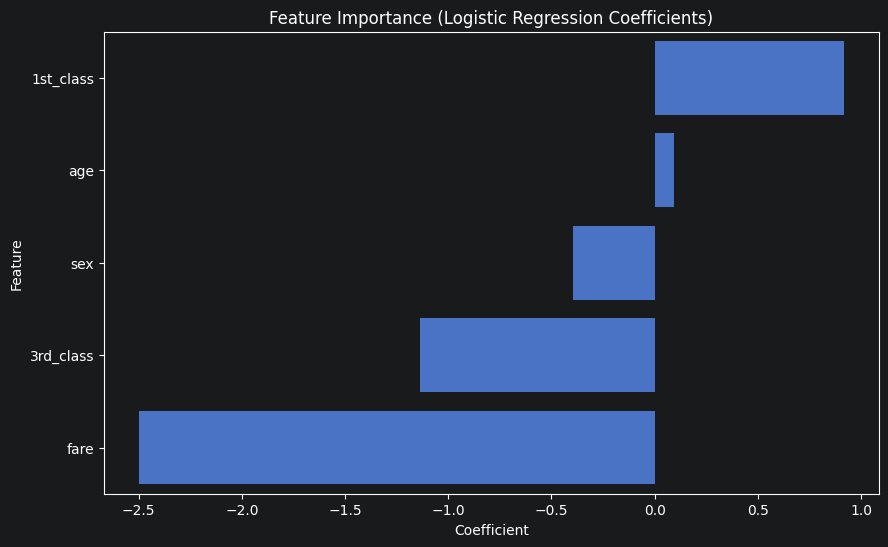

In [10]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
print(coefficients)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients
)

plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.show()


# 10. Conclusion

This notebook demonstrated a complete machine learning workflow using Scikit-learn.

The project included:

- Data preprocessing
- Feature scaling
- Logistic Regression training
- Classification evaluation
- ROC analysis
- Feature importance interpretation

The final model predicts Titanic passenger survival using supervised machine learning techniques.